**Why Decision Trees Overfit Here?**

High cardinality features

Categorical variables

Noisy boundaries

**Best Practices for Adult Dataset**
| Aspect            | Recommended             |
| ----------------- | ----------------------- |
| Criterion         | `entropy`               |
| max_depth         | 8–15                    |
| min_samples_leaf  | ≥ 50                    |
| min_samples_split | ≥ 100                   |
| Pruning           | Mandatory (`ccp_alpha`) |
| Scaling           | Not required            |


**Dataset Loading and Inspection**

In [1]:
import pandas as pd

adult_data = pd.read_csv('drive/MyDrive/Datasets For ML/Adult_Income_Dataset.csv')

print("Columns:", adult_data.columns)
print("\nShape:", adult_data.shape)
print("\nDuplicated Rows:", adult_data.duplicated().sum())
print("\nNull Values:", adult_data.isna().sum().sum())
print("\nFirst 5 rows:")
adult_data.head()

Columns: Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

Shape: (48842, 15)

Duplicated Rows: 52

Null Values: 0

First 5 rows:


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


**Data Cleaning**

In [2]:
adult_data.drop_duplicates(inplace=True)
print("Duplicated Rows After Cleaning:", adult_data.duplicated().sum())

Duplicated Rows After Cleaning: 0


**Handling Missing Values**

In the Adult dataset, missing values are often represented as "?".

In [3]:
adult_data.replace(" ?", pd.NA, inplace=True)
adult_data.dropna(inplace=True)

print("Shape After Removing Missing Values:", adult_data.shape)

Shape After Removing Missing Values: (48790, 15)


**Drop Low-Value or Redundant Columns**

education duplicates education-num.

fnlwgt not useful for prediction.

In [4]:
adult_data.drop(columns=['fnlwgt', 'education'], inplace=True)
print("Shape after dropping fnlwgt and education:", adult_data.shape)

Shape after dropping fnlwgt and education: (48790, 13)


**Feature–Label Separation**

In [5]:
X = adult_data.drop('income', axis=1)
Y = adult_data['income']

**Encoding Categorical Variables**

Decision Trees require numerical input.

In [6]:
from sklearn.preprocessing import LabelEncoder

cat_cols = X.select_dtypes(include='object').columns

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

print("Shape after encoding:", X.shape)

Shape after encoding: (48790, 12)


**Note:**

Scaling is not required for Decision Trees

Label Encoding preserves tree interpretability

**Train–Test Split (Stratified)**

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=5)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (39032, 12)
Test Shape: (9758, 12)


**Baseline Decision Tree (Severe Overfitting)**

In [8]:
from sklearn.tree import DecisionTreeClassifier

dt_base = DecisionTreeClassifier(random_state=5)
dt_base.fit(X_train, Y_train)

print("Training Accuracy:", dt_base.score(X_train, Y_train))
print("Testing Accuracy:", dt_base.score(X_test, Y_test))

Training Accuracy: 0.9742006558721049
Testing Accuracy: 0.8170731707317073


**Observation:**

The Decision Tree achieves very high training accuracy (≈97%), while the testing accuracy is considerably lower (≈82%).

This large performance gap indicates that the model is overfitting the training data by learning noise and dataset-specific patterns rather than general decision rules.

**Controlled Decision Tree (Best Practices Applied)**

In [9]:
dt_controlled = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    min_samples_leaf=50,
    min_samples_split=100,
    class_weight='balanced',
    random_state=5
)

dt_controlled.fit(X_train, Y_train)

print("Train Accuracy:", dt_controlled.score(X_train, Y_train))
print("Test Accuracy:", dt_controlled.score(X_test, Y_test))

Train Accuracy: 0.806184668989547
Test Accuracy: 0.7992416478786637


**Result:**

Reduced gap between train and test accuracy

Improved generalization

**Cost Complexity Pruning (Mandatory)**

In [10]:
path = dt_controlled.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas = path.ccp_alphas

acc = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(
        criterion='entropy',
        max_depth=10,
        min_samples_leaf=50,
        min_samples_split=100,
        class_weight='balanced',
        ccp_alpha=alpha,
        random_state=5
    )
    model.fit(X_train, Y_train)
    acc.append(model.score(X_test, Y_test))

print("Testing Accuracy:", acc)

Testing Accuracy: [0.7992416478786637, 0.7992416478786637, 0.7992416478786637, 0.7992416478786637, 0.7992416478786637, 0.7992416478786637, 0.7992416478786637, 0.7992416478786637, 0.7999590079934413, 0.7999590079934413, 0.7999590079934413, 0.7999590079934413, 0.7999590079934413, 0.7999590079934413, 0.7999590079934413, 0.7999590079934413, 0.8025210084033614, 0.8025210084033614, 0.8025210084033614, 0.8025210084033614, 0.8025210084033614, 0.8025210084033614, 0.8025210084033614, 0.8025210084033614, 0.8025210084033614, 0.8025210084033614, 0.8025210084033614, 0.8025210084033614, 0.8025210084033614, 0.8025210084033614, 0.805287968846075, 0.805287968846075, 0.805287968846075, 0.805287968846075, 0.805287968846075, 0.805287968846075, 0.805287968846075, 0.805287968846075, 0.804263168682107, 0.804263168682107, 0.804263168682107, 0.804263168682107, 0.8034433285509326, 0.8034433285509326, 0.8034433285509326, 0.8041606886657102, 0.8050830088132814, 0.8050830088132814, 0.8050830088132814, 0.80508300881

**Alpha vs Accuracy Plot**

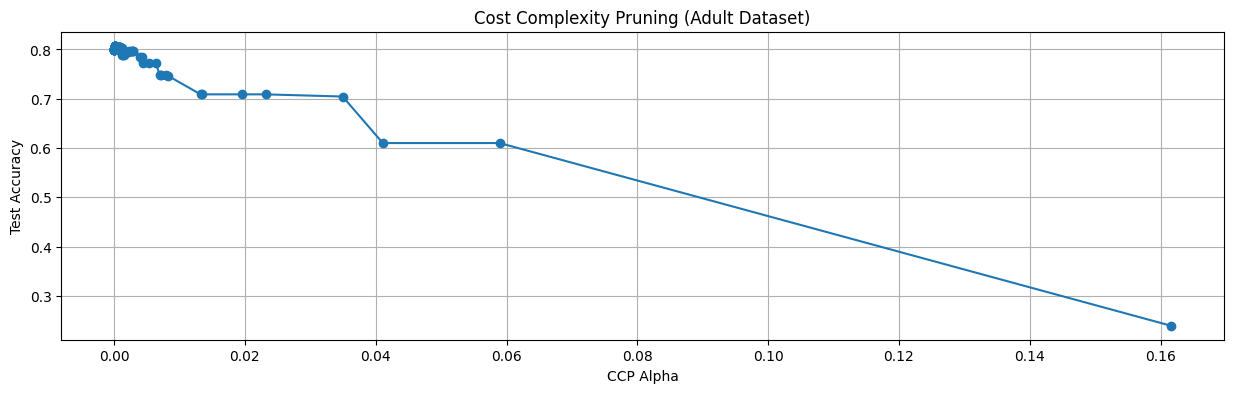

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
plt.plot(ccp_alphas, acc, marker='o')
plt.xlabel("CCP Alpha")
plt.ylabel("Test Accuracy")
plt.title("Cost Complexity Pruning (Adult Dataset)")
plt.grid(True)
plt.show()

**Final Best Model (Adult Income)**

In [12]:
best_alpha = ccp_alphas[acc.index(max(acc))]

best_dt_adult = DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=50, min_samples_split=100, class_weight='balanced', ccp_alpha=best_alpha, random_state=5)

best_dt_adult.fit(X_train, Y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0001436827793701444),
                       class_weight='balanced', criterion='entropy',
                       max_depth=10, min_samples_leaf=50, min_samples_split=100,
                       random_state=5)

**Decision Tree Visualization (Truncated for Readability)**

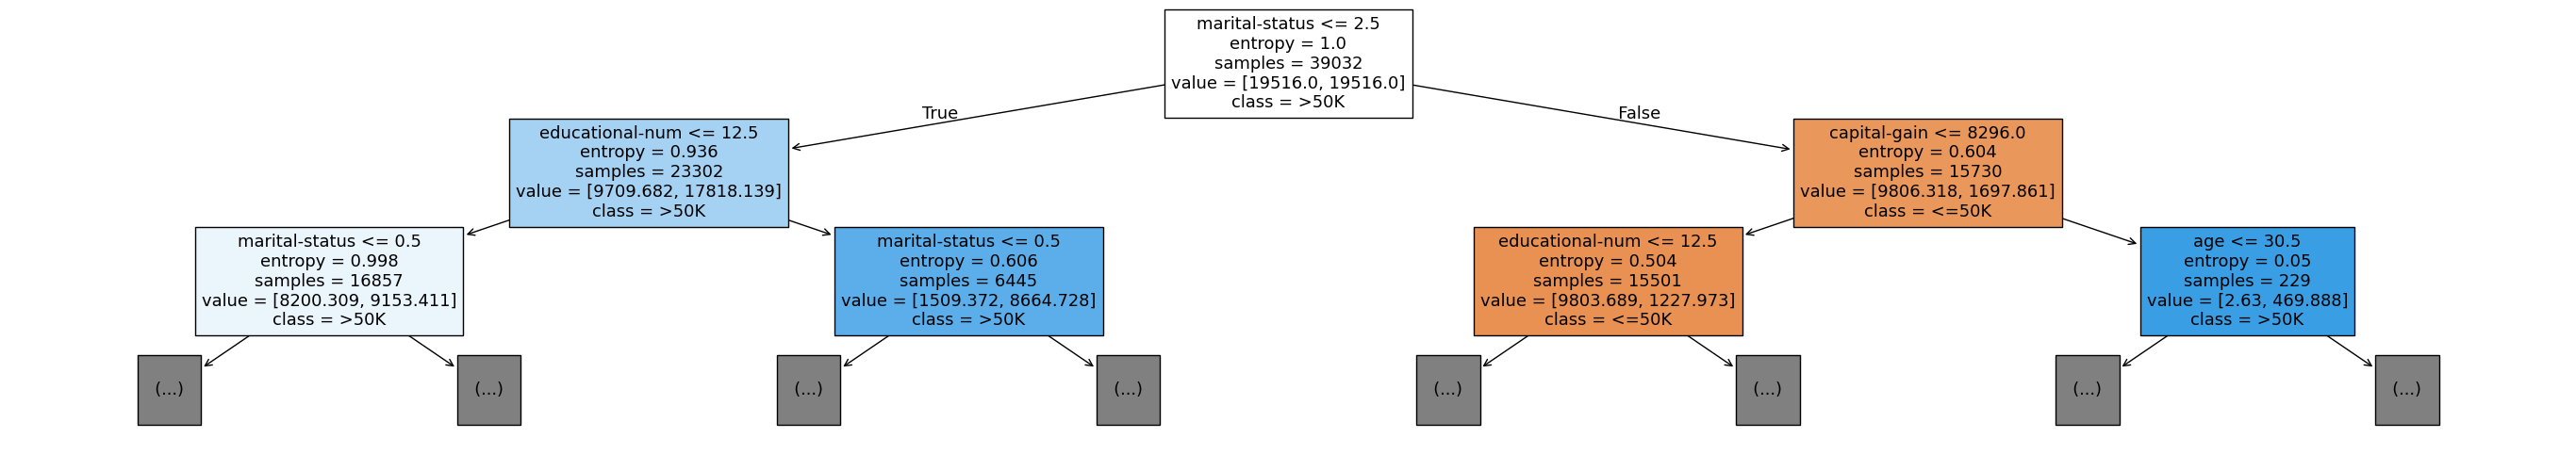

In [19]:
from sklearn.tree import plot_tree

plt.figure(figsize=(35, 6))
plot_tree(best_dt_adult, feature_names=X.columns, class_names=best_dt_adult.classes_, max_depth=2, filled=True)
plt.show()

**Model Evaluation**

In [14]:
from sklearn import metrics

Y_pred = best_dt_adult.predict(X_test)

print("Accuracy:", metrics.accuracy_score(Y_test, Y_pred))
print("\nClassification Report:\n", metrics.classification_report(Y_test, Y_pred))
print("Confusion Matrix:\n", metrics.confusion_matrix(Y_test, Y_pred))

Accuracy: 0.8075425292068047

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86      7422
        >50K       0.57      0.83      0.67      2336

    accuracy                           0.81      9758
   macro avg       0.75      0.81      0.77      9758
weighted avg       0.85      0.81      0.82      9758

Confusion Matrix:
 [[5946 1476]
 [ 402 1934]]


**Conclusion**

Decision Trees tend to overfit on large categorical datasets. Using entropy with pruning and sample constraints improves performance. Without pruning, datasets like Adult cannot be modeled reliably. Visualizations show that pruning reduces tree complexity and enhances generalization.
